In [1]:
import matplotlib.pyplot as plt
import os
import json
import model_helpers as mh
from neuron import h, load_mechanisms
%matplotlib inline

--No graphics will be displayed.


## Define model

In [2]:
code_version = 'Allen'

In [3]:
model_version = 'NEURON'

if 'Hay' in code_version:
    nmldb_id = 'NMLCL000073'  # 'NMLCL000073' (Hay et al. 2011)
    model_name = f'{nmldb_id}-{model_version}'

    cell_model = 'Hay2011'  # 'Hay2011'
    cell_type = 'PYR'
    cell_name = 'L5PC'  # 'L5PC'
else:
    nmldb_id = 'NMLCL001535'  # 'NMLCL000073' (Hay et al. 2011)
    model_name = f'{nmldb_id}-{model_version}'

    cell_model = 'Allen'  # 'Hay2011'
    cell_type = 'PYR'
    cell_name = 'Cell_473863035'  # 'L5PC'


## Define paths

In [4]:
hoc_name = cell_name  # 'L5PC'

cwd = os.getcwd()
models_dir = os.path.join(cwd, 'models')
model_dir = os.path.join(models_dir, model_version, model_name)  # 'L5bPCmodelsEH')
hocs_dir = model_dir if 'biophys' not in model_name else os.path.join(model_dir,'models')
mod_dir = model_dir if 'biophys' not in model_name else os.path.join(model_dir, 'mod')


## Download model

In [5]:
mh.download_from_nmldb(nmldb_id, model_version)

Model NMLCL001535 already downloaded.


In [6]:
output_dir = os.path.join(model_dir,'output')
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

## Compile mechanisms

In [7]:
mh.compile_mechs(cwd,hocs_dir,mod_dir)
load_mechanisms(model_dir)

Mechanisms already compiled!


True

## Import cell into NetPyNE

In [8]:
hoc_file = os.path.join(hocs_dir, cell_name+'.hoc')

In [9]:
from netpyne import specs, sim

# Network parameters
netParams = specs.NetParams()

In [10]:
cell_label = cell_name+'_hoc'

netParams.importCellParams(
    label=cell_label,
    conds={'cellType': cell_type, 'cellModel': cell_model},
    fileName=hoc_file,
    cellName=cell_name,
    importSynMechs=False
)

	1 


{conds: {cellType: 'PYR', cellModel: 'Allen'}, secs: {soma_0: {geom: {L: 12.881011962890625, nseg: 1, diam: 12.881199836730957, Ra: 122.880005, cm: 1.0, pt3d: [(-6.44000244140625, 0.0, 0.0, 12.881199836730957), (0.0, 0.0, 0.0, 12.881199836730957), (6.441009521484375, 0.0, 0.0, 12.881199836730957)]}, topol: {}, mechs: {CaDynamics: {gamma: 0.0264831, minCai: 0.0001, decay: 739.8, depth: 0.1, Faraday: 0.0964853, AREA_SCALE: 1000000000000.0, LENGTH_SCALE: 1000000.0}, Ca_HVA: {gmax: 0.00097272184, conductance: 1e-05, m_instances: 2.0, m_forwardRate_rate: 0.209, m_forwardRate_midpoint: -27.0, m_forwardRate_scale: 3.8, m_reverseRate_rate: 0.94, m_reverseRate_midpoint: -75.0, m_reverseRate_scale: -17.0, h_instances: 1.0, h_forwardRate_rate: 0.000457, h_forwardRate_midpoint: -13.0, h_forwardRate_scale: -50.0, h_reverseRate_rate: 0.0065, h_reverseRate_midpoint: -15.0, h_reverseRate_scale: 28.0}, Ca_LVA: {gmax: 0.0066296505, conductance: 1e-05, m_instances: 2.0, m_timeCourse_TIME_SCALE: 1.0, m_ti

In [11]:
netParams.cellParams.keys()

odict_keys(['Cell_473863035_hoc'])

In [12]:
netParams.cellParams[cell_label]['secs'].keys()

dict_keys(['soma_0', 'axon_0', 'dend_26', 'apic_0', 'dend_17', 'dend_0', 'axon_1', 'apic_6', 'apic_1', 'dend_19', 'dend_18', 'dend_8', 'dend_1', 'apic_8', 'apic_7', 'apic_5', 'apic_2', 'dend_23', 'dend_20', 'dend_16', 'dend_9', 'dend_5', 'dend_2', 'apic_4', 'apic_3', 'dend_25', 'dend_24', 'dend_22', 'dend_21', 'dend_13', 'dend_10', 'dend_7', 'dend_6', 'dend_4', 'dend_3', 'dend_15', 'dend_14', 'dend_12', 'dend_11'])

## Create Population

In [13]:
pop_label = cell_label+'_pop'
netParams.popParams[pop_label] = {'cellType': cell_type, 'numCells': 1, 'cellModel': cell_model}

## Simulation Configuration

In [14]:
if 'Hay' in code_version:
    input_amps = [0.35477, 0.44346, 0.53215, 1.0643]
else:
    input_amps = [0.10574, 0.13218, 0.15862, 0.31723]

amp_idx = -1  # -1 = no input
input_amp = input_amps[amp_idx]
test_label = f'input_{amp_idx}-test'
# test_label = f'no_input-new_v_init'

In [15]:
## cfg
cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration
cfg.duration = 3000 						            # Duration of the simulation, in ms
cfg.dt = 0.01								                # Internal integration timestep to use
cfg.verbose = 1							                # Show detailed messages
cfg.recordTraces = {'V_soma':{'sec':'soma_0','loc':0.5,'var':'v'}}  # Dict with traces to record
cfg.recordStep = 0.01
cfg.filename = os.path.join(output_dir,cell_name+'_'+test_label) 			# Set file output name
cfg.saveJson = False
cfg.analysis['plotTraces'] = {'include': [pop_label], 'saveFig': True} # Plot recorded traces for this list of cells
cfg.hParams['celsius'] = 34  # 36
cfg.hParams['v_init'] = -89.26

## Add Input

In [16]:
if amp_idx > -1:
    netParams.stimSourceParams['Input_IC'] = {
        'type': 'IClamp',
        'del': 700,
        'dur': 2000,
        'amp': input_amp  
    }

    netParams.stimTargetParams['Input_IC->Soma'] = {
        'source': 'Input_IC',
        'sec': 'soma_0',
        'loc': 0.5,
        'conds': {'pop': pop_label}
    }

## Run Simulation

In [17]:
sim.createSimulateAnalyze(netParams = netParams, simConfig = cfg)


Start time:  2023-11-30 19:35:56.576332

Creating network of 1 cell populations on 1 hosts...
Distributed population of 1 cells on 1 hosts: {0: [0]}, next: 0
Cell 0/0 (gid=0) of pop Cell_473863035_hoc_pop, on node 0, 
Instantiated 1 cells of population Cell_473863035_hoc_pop
  Number of cells on node 0: 1 
  Done; cell creation time = 0.02 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
  Number of stims on node 0: 0 
  Done; cell stims creation time = 0.00 s.
  Recording  V_soma from cell  0  with parameters:  {'sec': 'soma_0', 'loc': 0.5, 'var': 'v'}
Vector[2]
   Recording: spkt:
   Recording: spkid:
   Recording: V_soma:
      cell_0
   Recording: t:
Recording 1 traces of 1 types on node 0

Setting h global variables ...
  h.celsius = 34
  h.v_init = -89.26
  h.clamp_resist = 0.001
  h.tstop = 3000.0
Minimum delay (time-step for queue exchange) is 10.00

Running simulation using NEURON for 3000.0 ms...
  Done; run time = 3.06 s;

## Run in NEURON

In [19]:
from neuron.units import mV, ms
%matplotlib inline

h.load_file('stdrun.hoc')
h.load_file(hoc_file)

1.0

In [20]:
h.cvode_active(0)
h.tstop = 3000 * ms
h.celsius = 34
h.steps_per_ms = 100
h.dt = 1.0 / h.steps_per_ms
h.finitialize(-89.26 * mV)

1.0

In [21]:
hoc_cell = getattr(h, cell_name)
hoc_cell()

Cell_473863035[0]

In [22]:
cell = hoc_cell[0]
soma = cell.soma_0

In [35]:
if 'Hay' in code_version:
    input_amps = [0, 0.35477, 0.44346, 0.53215, 1.0643]
else:
    input_amps = [0, 0.10574, 0.13218, 0.15862, 0.31723]

ts = []
vs = []

for idx, input_amp in enumerate(input_amps):

    ic = h.IClamp(soma(0.5))
    ic.delay = 700*ms
    ic.dur = 2000*ms
    ic.amp = input_amp

    t = h.Vector().record(h._ref_t)
    v = h.Vector().record(soma(0.5)._ref_v)

    h.run()

    ts.append(list(t))
    vs.append(list(v))

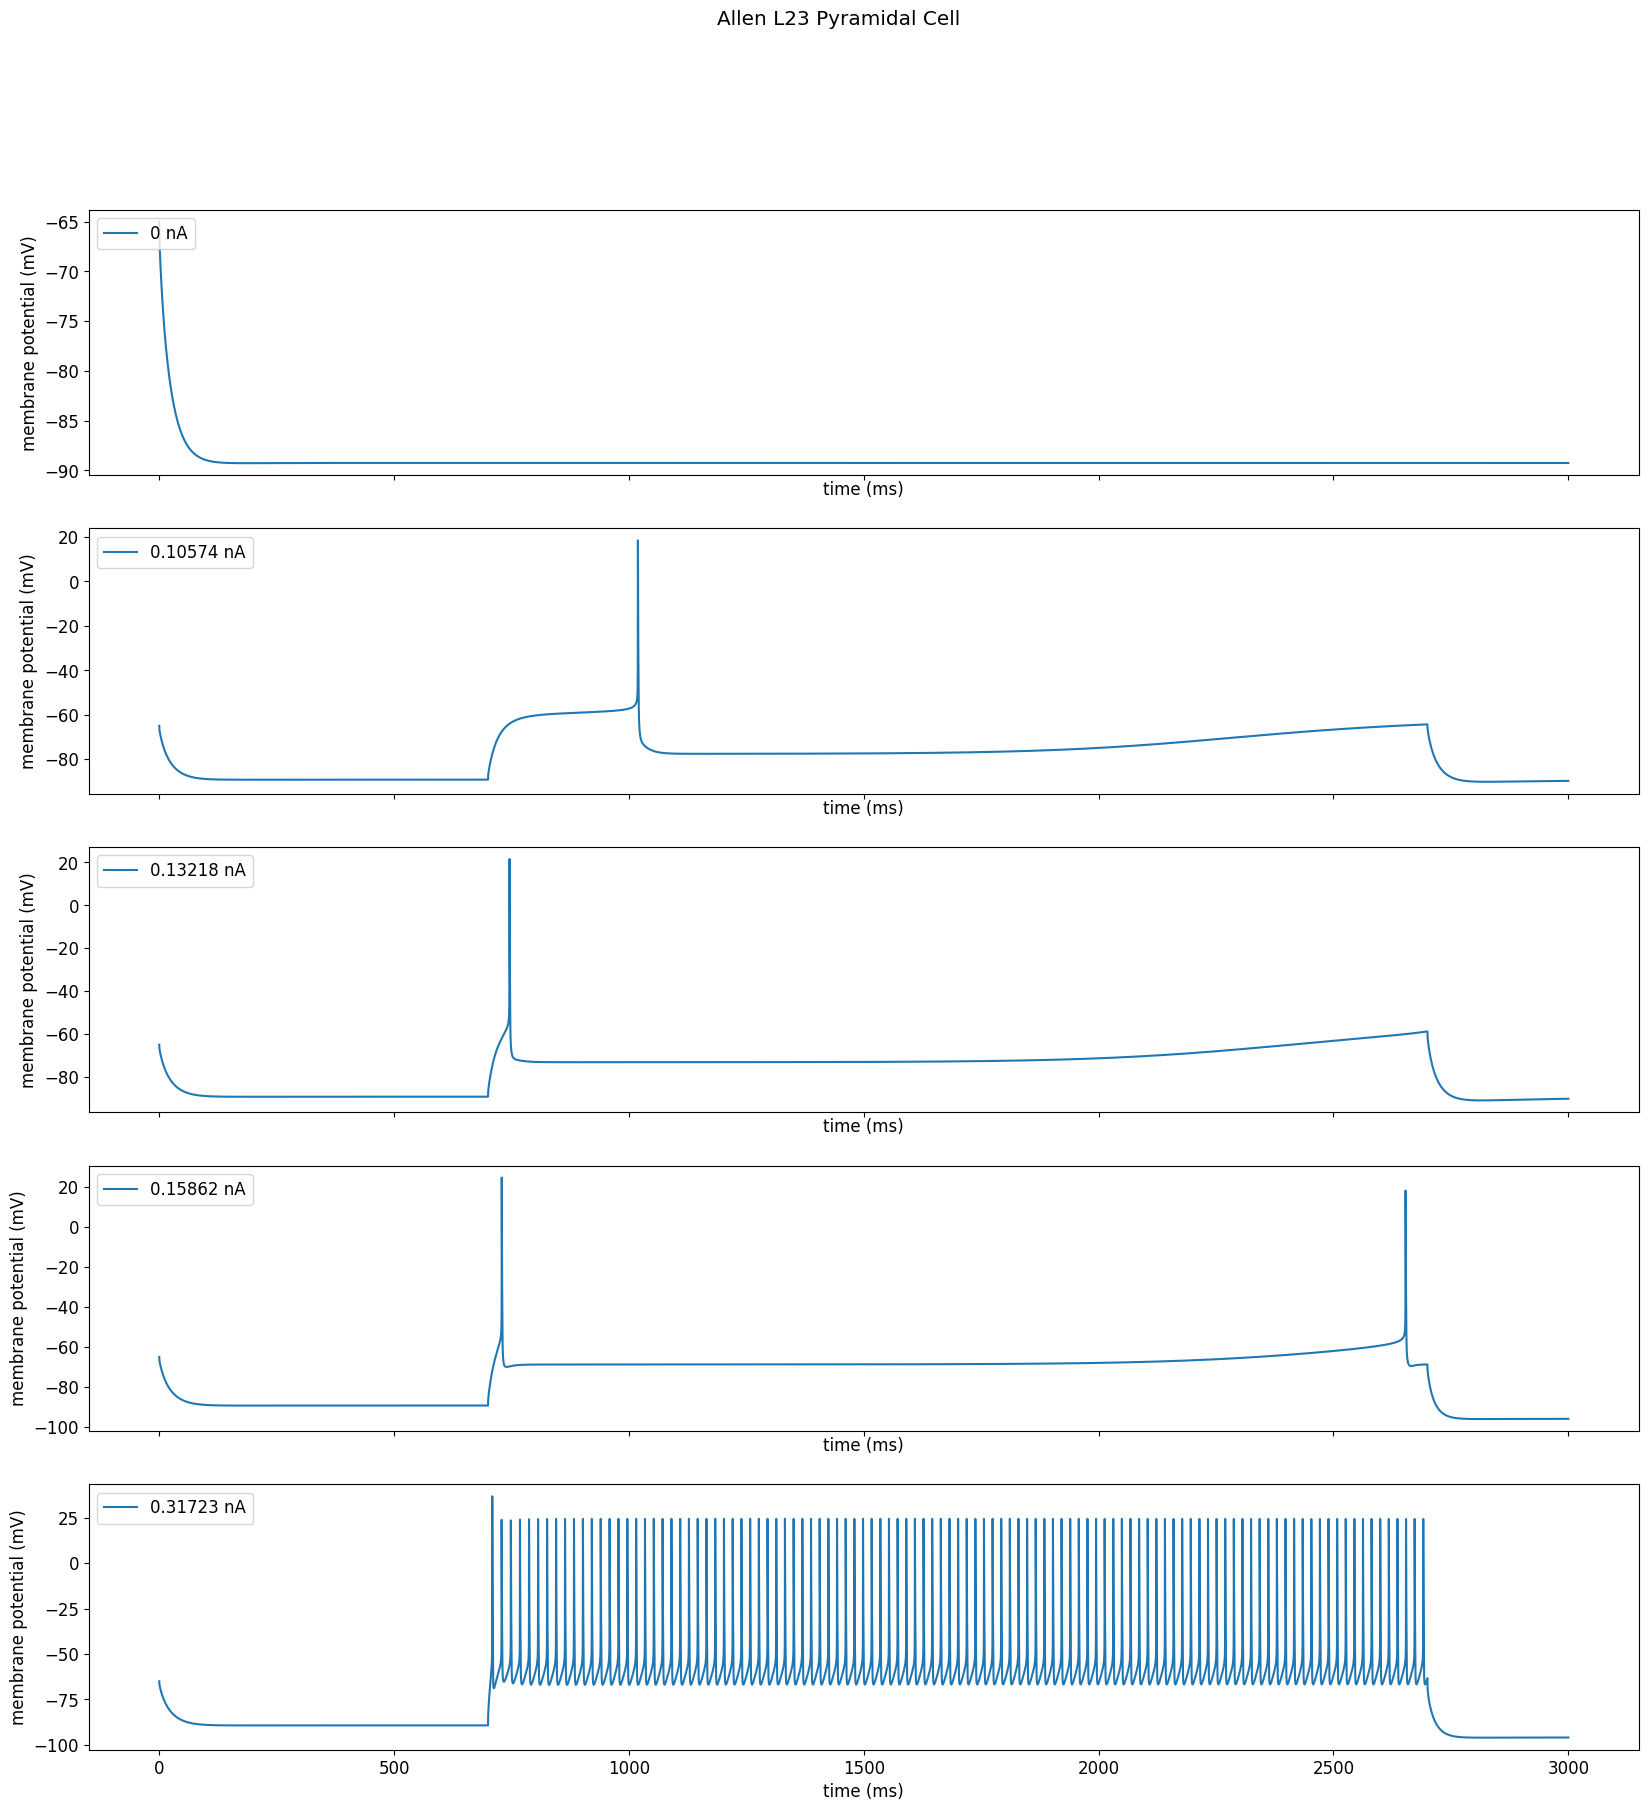

In [36]:
fig, axs = plt.subplots(len(input_amps), 1, figsize=(20,20), sharex=True)
axs = axs.ravel()

for idx, (t, v) in enumerate(zip(ts, vs)):

    axs[idx].plot(list(t),list(v),label=f'{input_amps[idx]} nA')
    
    axs[idx].legend(loc='upper left')
    axs[idx].set_xlabel('time (ms)')
    axs[idx].set_ylabel('membrane potential (mV)')

if 'Hay' in code_version:
    fig.suptitle('Hay 2011 L5 Pyramidal Cell')
else:
    fig.suptitle('Allen L23 Pyramidal Cell')

fig.savefig(os.path.join(output_dir,cell_name+'_NEURON-sims.jpg'), dpi=300)

In [31]:
os.path.join(output_dir,cell_name+'_NEURON-sims.jpg')

'/home/kedoxey/CRCNS/PyramidalCellSimulations/models/NEURON/NMLCL000073-NEURON/output/L5PC_NEURON-sims.jpg'

## Plot Morphology

In [20]:
sim.analysis.plotShape(includePre = [], includePost=[pop_label], showSyns=False, figSize=(4,9), dist=0.8, saveFig=True)

Plotting 3D cell shape ...


(<Figure size 400x900 with 1 Axes>, {})